In [ ]:
# 1. Installation normale (plus besoin de forcer d'anciennes versions !)
!pip install -q datasets matplotlib pandas numpy

import datasets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datasets import load_dataset
from collections import Counter

print(f"Version de datasets active : {datasets.__version__}")

Version de datasets active : 4.0.0


In [ ]:
# CHARGEMENT DU DATASET

print("\n loading the dataset...")
# On utilise un dépôt miroir parfait qui contient exactement les 54 306 images au format Parquet
dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")

train_ds = dataset["train"]
test_ds = dataset["test"]

print("Loading done")
print(f"Training images: {len(train_ds)}")
print(f"Test Images: {len(test_ds)}\n")


 loading the dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

Loading done
Training images: 43456
Test Images: 10849



In [ ]:
from datasets import load_dataset, concatenate_datasets, DatasetDict

print("\nLoading the dataset...")
dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")

# get the data together
full_dataset = concatenate_datasets([dataset["train"], dataset["test"]])

print("\n Creation of the new split(70% Train, 15% Val, 15% Test)...")

# 70%  30%
train_testvalid = full_dataset.train_test_split(test_size=0.3, seed=42)

# 30% -> 15% / 15%
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

# clean re-package
custom_dataset = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})

# On met à jour nos variables
train_ds = custom_dataset["train"]
val_ds = custom_dataset["validation"]
test_ds = custom_dataset["test"]


print(f"Training images (70%): {len(train_ds)}")
print(f"Validation images (15%): {len(val_ds)}")
print(f"Test Images (15%): {len(test_ds)}\n")


Loading the dataset...

 Creation of the new split(70% Train, 15% Val, 15% Test)...
Training images (70%): 38013
Validation images (15%): 8146
Test Images (15%): 8146



In [ ]:
# IDENTIFICATION DES CLASSES

# Gestion robuste selon comment le miroir a encodé les labels
feature_label = train_ds.features['label']
if hasattr(feature_label, 'names'):
    class_names = feature_label.names
else:
    # Si les labels sont déjà des textes au lieu de chiffres
    class_names = sorted(list(set(train_ds['label'])))

print(f"Number of classes : {len(class_names)}")


Number of classes : 38


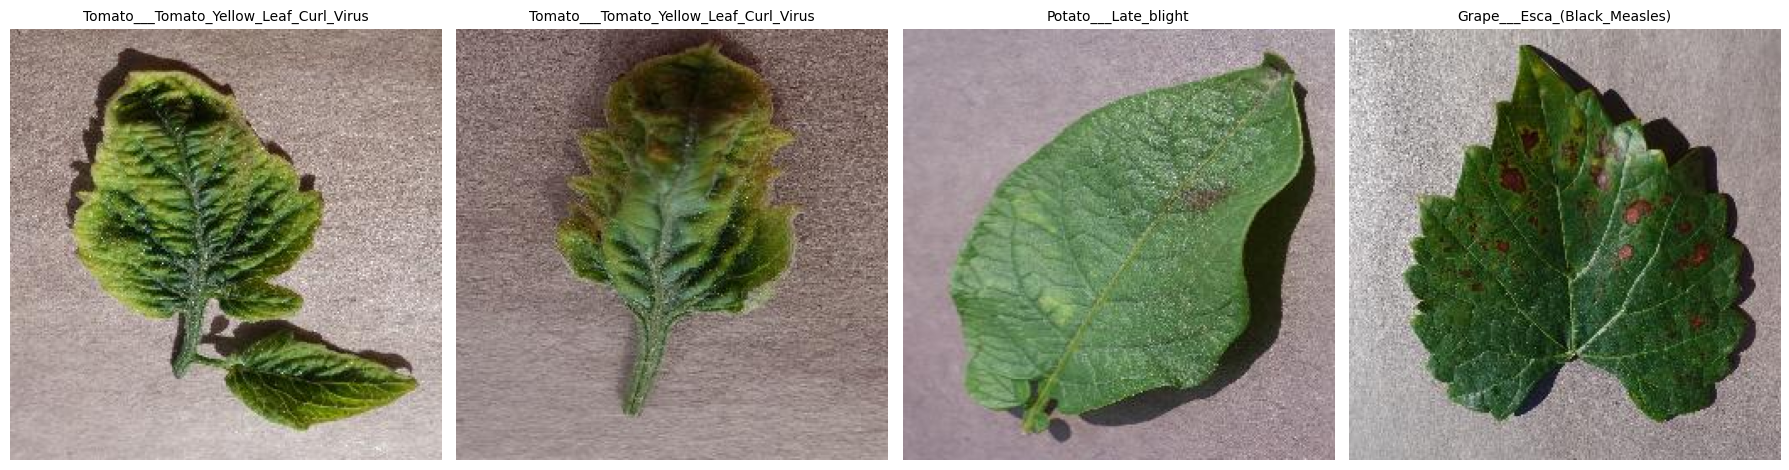

In [ ]:
# VISUALISATION DE LA GALERIE

plt.figure(figsize=(18, 6))
indices = np.random.choice(len(train_ds), 4, replace=False)

for i, idx in enumerate(indices):
    sample = train_ds[int(idx)]

    plt.subplot(1, 4, i + 1)
    plt.imshow(sample['image'])

    # Récupération du nom de la classe
    valeur_label = sample['label']
    nom_classe = class_names[valeur_label] if isinstance(valeur_label, int) else valeur_label

    plt.title(f"{nom_classe}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

 Distribution of images per classes...


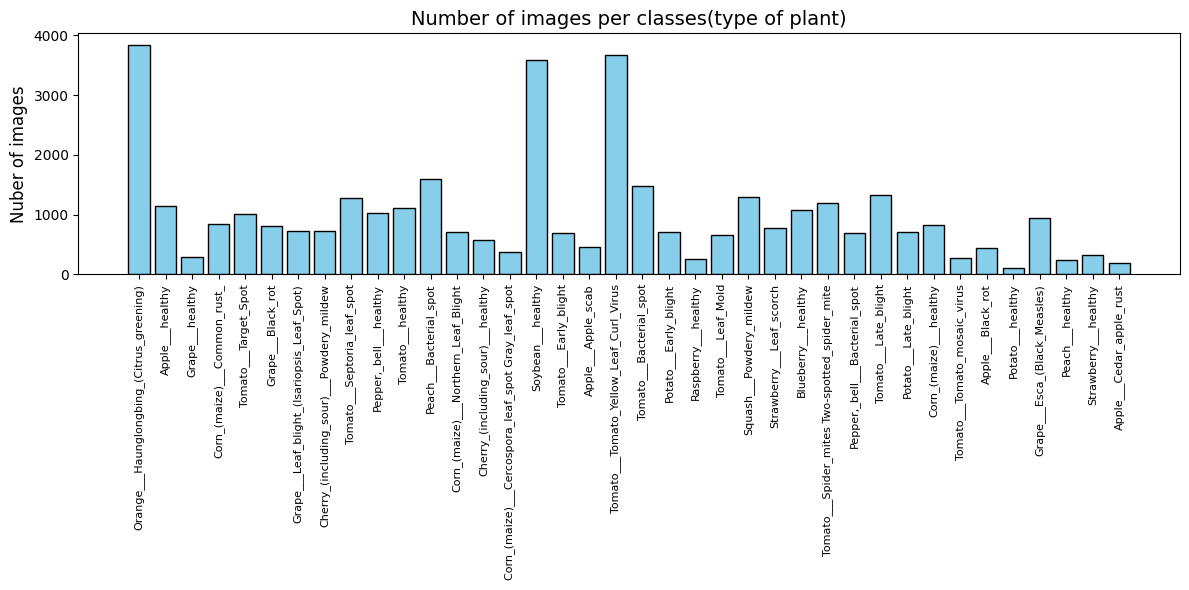

In [ ]:
print(" Distribution of images per classes...")

# Comptage des images pour chaque classe
labels = [sample['label'] for sample in train_ds]
counts = Counter(labels)

# On remplace les ID par les vrais noms
noms_labels = [class_names[k] if isinstance(class_names[k], str) else f"Classe {k}" for k in counts.keys()]
valeurs = list(counts.values())

# Création d'un beau graphique
plt.figure(figsize=(12, 6))
plt.bar(noms_labels, valeurs, color='skyblue', edgecolor='black')
plt.xticks(rotation=90, fontsize=8) # On tourne les noms pour que ce soit lisible
plt.title("Number of images per classes(type of plant)", fontsize=14)
plt.ylabel("Nuber of images", fontsize=12)
plt.tight_layout()
plt.show()

simulation of data AUgmentation in one leaf...


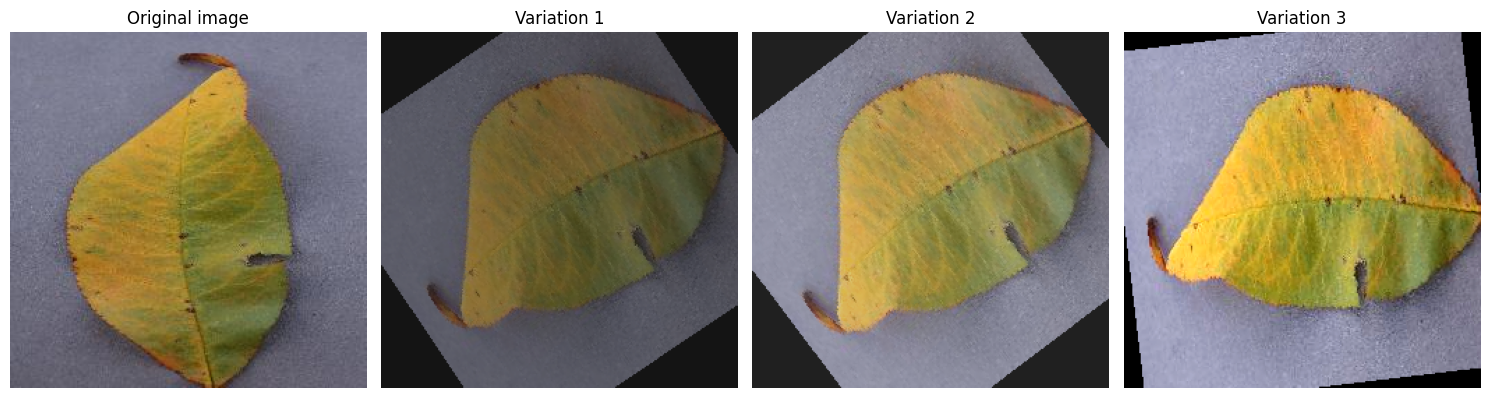

In [ ]:

# DATA AUGMENTATION (SIMULATION)
import torchvision.transforms as transforms

print("simulation of data AUgmentation in one leaf...")


augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0), # Effet miroir
    transforms.RandomRotation(degrees=180),  # Rotation aléatoire jusqu'à 180 degrés
    transforms.ColorJitter(brightness=0.3, contrast=0.3) # Changement de lumière
])


image_originale = train_ds[100]['image']

plt.figure(figsize=(15, 4))

# Affichage de l'originale
plt.subplot(1, 4, 1)
plt.imshow(image_originale)
plt.title("Original image")
plt.axis('off')

# Affichage de 3 variations
for i in range(2, 5):
    image_augmentee = augmentation(image_originale)
    plt.subplot(1, 4, i)
    plt.imshow(image_augmentee)
    plt.title(f"Variation {i-1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

# PRÉPARATION POUR LE RÉSEAU DE NEURONES (PREPROCESSING)
print("Redimention and convertion in Tensors...")

preprocessing = transforms.Compose([
    transforms.Resize((224, 224)), # standard for ResNet/MobileNet
    transforms.ToTensor()          # Conversion of images in matrix of numbers (0 to 1)
])

image_test = train_ds[0]['image']
tenseur = preprocessing(image_test)

print(f"original : {image_test.size} (Pixels)")
print(f"After preprocessing : {tenseur.shape} tensor shape")
print(f"Mathématic value of first pixel : {tenseur[0][0][0]:.4f}")

Redimention and convertion in Tensors...
original : (256, 256) (Pixels)
After preprocessing : torch.Size([3, 224, 224]) tensor shape
Mathématic value of first pixel : 0.5333


In [ ]:
import pandas as pd

# On part du principe que la variable class_names contient ta liste brute des 38 classes
noms_plantes = []
etats_maladies = []

for nom_brut in class_names:
    # On sépare au niveau des "___" (les 3 tirets du bas)
    parts = nom_brut.split("___")

    # On remplace les tirets du bas restants par des espaces pour faire plus propre
    plante = parts[0].replace("_", " ")
    etat = parts[1].replace("_", " ")

    noms_plantes.append(plante)
    etats_maladies.append(etat)

# Création du DataFrame complet
df_clean = pd.DataFrame({
    "ID": range(len(class_names)),
    "Nom Original": class_names,       # La catégorie brute du dataset
    "Plante": noms_plantes,            # Le nom de la plante nettoyé
    "État / Maladie": etats_maladies   # L'état ou la maladie nettoyé
})

# Affiche le tableau dans Colab
display(df_clean)

,ID,Nom Original,Plante,État / Maladie
0,0,Apple___Apple_scab,Apple,Apple scab
1,1,Apple___Black_rot,Apple,Black rot
2,2,Apple___Cedar_apple_rust,Apple,Cedar apple rust
3,3,Apple___healthy,Apple,healthy
4,4,Blueberry___healthy,Blueberry,healthy
5,5,Cherry_(including_sour)___Powdery_mildew,Cherry (including sour),Powdery mildew
6,6,Cherry_(including_sour)___healthy,Cherry (including sour),healthy
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot
8,8,Corn_(maize)___Common_rust_,Corn (maize),Common rust
9,9,Corn_(maize)___Northern_Leaf_Blight,Corn (maize),Northern Leaf Blight


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

print("Préparation des images pour PyTorch...")

# 1. On définit les transformations (Redimensionnement + Normalisation standard)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Petite data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. On applique ces transformations à nos datasets Hugging Face
def apply_transforms_train(examples):
    examples['pixel_values'] = [transform_train(image.convert("RGB")) for image in examples['image']]
    return examples

def apply_transforms_test(examples):
    examples['pixel_values'] = [transform_test(image.convert("RGB")) for image in examples['image']]
    return examples

train_ds.set_transform(apply_transforms_train)
val_ds.set_transform(apply_transforms_test)
test_ds.set_transform(apply_transforms_test)

# 3. Création des DataLoaders (qui vont envoyer les images par paquets/batchs de 32 au modèle)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print("DataLoaders prêts !")

Préparation des images pour PyTorch...
DataLoaders prêts !


In [ ]:
print("Chargement du modèle ResNet18...")

# On utilise le GPU si Colab en fournit un, sinon le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

# Chargement de ResNet18 pré-entraîné
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# On modifie la dernière couche (fully connected) pour nos 38 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 38)

# On envoie le modèle sur la carte graphique
model = model.to(device)

# Définition de la fonction de perte (Loss) et de l'optimiseur (qui met à jour les poids)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Modèle prêt à être entraîné !")

Chargement du modèle ResNet18...
Appareil utilisé : cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Modèle prêt à être entraîné !


In [ ]:
print("Début de l'entraînement (1 Epoch)...")

# --- PHASE D'ENTRAÎNEMENT ---
model.train()
running_loss = 0.0

# On ne prend que les 100 premiers batchs pour l'exemple (à enlever pour un vrai entraînement)
for i, batch in enumerate(train_loader):
    inputs = torch.stack(batch['pixel_values']).to(device)
    labels = batch['label'].to(device)

    # Remise à zéro des gradients
    optimizer.zero_grad()

    # Prédiction (Forward)
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # Apprentissage (Backward)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if i % 20 == 0: # Affiche l'avancement tous les 20 batchs
        print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

# --- PHASE DE VALIDATION (Calcul de l'Accuracy) ---
print("\n🧪 Calcul de l'Accuracy sur le set de Validation...")
model.eval()
correct = 0
total = 0

with torch.no_grad(): # On n'apprend pas ici, on évalue juste
    for batch in val_loader:
        inputs = torch.stack(batch['pixel_values']).to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1) # On prend la classe avec la plus haute probabilité

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nPrécision (Accuracy) sur la Validation : {accuracy:.2f}%")

Début de l'entraînement (1 Epoch)...


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.JpegImagePlugin.JpegImageFile'>